# Notebook \#4: Running Predictions (Inference) </br>and Anomaly Detection
---

---

## Running Predictions

In [ ]:
# Load the model


In [ ]:
# Find the longest sequence in the test data
test_session_ids = test_df["id"].unique()
print(test_session_ids)

# Filter the test DataFrame for the selected session
max_id = 0
max_len = 0
for i in range(len(test_session_ids)):
    selected_sessions_id = test_session_ids[i]
    selected_sessions_df = test_df[test_df['id'] == selected_sessions_id]
    if len(selected_sessions_df) > max_len:
        max_len = len(selected_sessions_df)
        max_id = selected_sessions_id

print(f"Max length: {max_len}, ID: {max_id}")

[23790, 23791, 23792, 23793, 23794, ..., 29838, 29839, 29840, 29841, 29842]
Length: 5983
Categories (29474, int64): [1, 2, 3, 4, ..., 29839, 29840, 29841, 29842]
Max length: 312, ID: 26586


In [ ]:
# Selecting a random charging sessions
# test_session_ids = test_df["id"].unique()

# Filter the test DataFrame for the selected sessions
# selected_sessions_id = [test_session_ids[max_id]]
selected_sessions_df = test_df[test_df['id'] == max_id]
print(len(selected_sessions_df))

# Performs normalization
selected_sessions_df[features] = scaler.transform(selected_sessions_df[features])
# Create sequences 
X_test_selected, y_test_selected = create_sequences(selected_sessions_df, sequence_length)
print(f"Number of X sequences: {len(X_test_selected)}", f"\nNumber of y_true: {len(y_test_selected)}")

312


C:\Users\sebas\AppData\Local\Temp\ipykernel_28852\2975008867.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_sessions_df[features] = scaler.transform(selected_sessions_df[features])
C:\Users\sebas\AppData\Local\Temp\ipykernel_28852\1650400335.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for session_id, session_df in df.groupby('id'):


Number of X sequences: 282 
Number of y_true: 282


In [ ]:
# Run predictions on these sequences
session_predictions = list()
with torch.no_grad():
    for sequence in X_test_selected:
        seq_tensor = torch.tensor(sequence, dtype=torch.float).unsqueeze(0).to(device)
        print(seq_tensor)
        prediction = model(seq_tensor).cpu().numpy()
        print(prediction)
        session_predictions.append(prediction)

In [ ]:
pred_df = pd.DataFrame([pred[0] for pred in session_predictions], columns=["Power", "soc"])
pred_df

,Power,soc
0,0.014876,0.046510
1,0.014860,0.046512
2,0.014820,0.046548
3,0.014799,0.046520
4,0.014801,0.046538
...,...,...
277,0.013890,0.050539
278,0.013892,0.050567
279,0.013799,0.050574
280,0.013853,0.050578


            id                 timestamp       soc     power  minutes_elapsed  \
1100678  26586 2023-03-12 11:21:54+00:00 -0.000204  0.000219         0.003997   
1100679  26586 2023-03-12 11:22:14+00:00 -0.000204  0.000212         0.004010   
1100680  26586 2023-03-12 11:22:34+00:00 -0.000204  0.000207         0.004023   
1100681  26586 2023-03-12 11:22:54+00:00 -0.000204  0.000207         0.004036   
1100682  26586 2023-03-12 11:23:14+00:00 -0.000204  0.000201         0.004049   

         Power (predicted)  SOC (predicted)  
1100678           0.013890         0.050539  
1100679           0.013892         0.050567  
1100680           0.013799         0.050574  
1100681           0.013853         0.050578  
1100682           0.013854         0.050582  


C:\Users\sebas\AppData\Local\Temp\ipykernel_28852\1242518203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_sessions_df["Power (predicted)"] = 0
C:\Users\sebas\AppData\Local\Temp\ipykernel_28852\1242518203.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.01487552 0.01485994 0.01482002 0.01479875 0.01480059 0.01481228
 0.01478107 0.01481476 0.01484218 0.0148432  0.01481074 0.01475239
 0.01485746 0.01470129 0.01471148 0.01475997 0.01475433 0.01474197
 0.01477008 0.01470493 0.01464474 0.01464847 0.01476443 0.01475635
 0.01475975 0.01474425 0.01470837 0.01470499 0.01471804 0.01470967
 0.01470585 0.01469702 0.01468599 0.01468247 0.01463161 0.01461263

,id,timestamp,soc,power,minutes_elapsed,Power (predicted),SOC (predicted)
1100371,26586,2023-03-12 09:39:34+00:00,0.262626,0.132539,0.000000,1.000000,0.020000
1100372,26586,2023-03-12 09:39:54+00:00,0.262626,0.132539,0.002083,1.000000,0.020000
1100373,26586,2023-03-12 09:40:14+00:00,0.262626,0.132539,0.004167,1.000000,0.020000
1100374,26586,2023-03-12 09:40:34+00:00,0.262626,0.134369,0.006250,1.000000,0.020000
1100375,26586,2023-03-12 09:40:54+00:00,0.262626,0.132875,0.008333,1.000000,0.020000
...,...,...,...,...,...,...,...
1100678,26586,2023-03-12 11:21:54+00:00,0.979798,0.078575,0.639583,2.375128,13.552788
1100679,26586,2023-03-12 11:22:14+00:00,0.979798,0.076894,0.641667,2.375341,13.560229
1100680,26586,2023-03-12 11:22:34+00:00,0.979798,0.075401,0.643750,2.366138,13.562240
1100681,26586,2023-03-12 11:22:54+00:00,0.979798,0.075401,0.645833,2.371478,13.563401


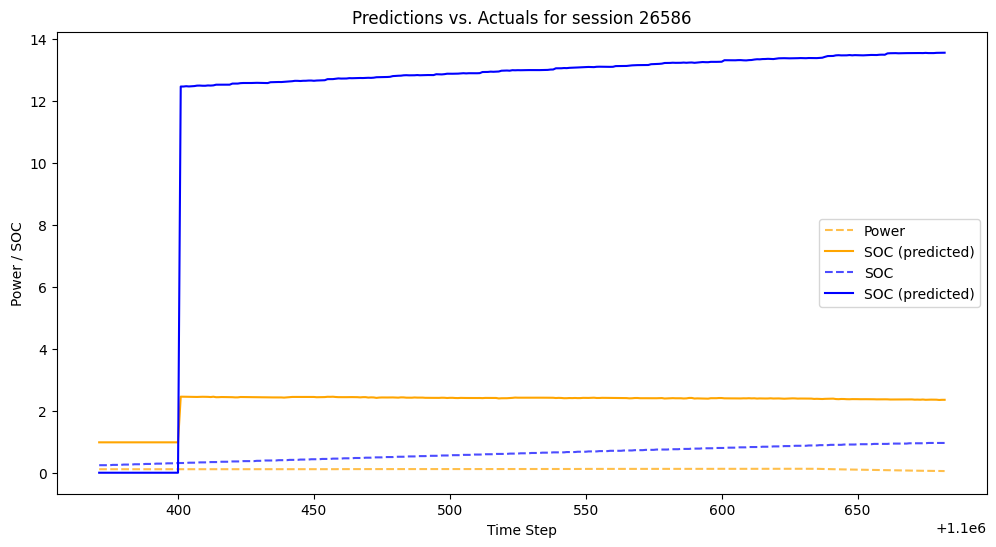

In [ ]:
# Add predictions to df
selected_sessions_df["Power (predicted)"] = 0
selected_sessions_df.iloc[-len(pred_df):, selected_sessions_df.columns.get_loc("Power (predicted)")] = pred_df["Power"]
selected_sessions_df["SOC (predicted)"] = 0
selected_sessions_df.iloc[-len(pred_df):, selected_sessions_df.columns.get_loc("SOC (predicted)")] = pred_df["soc"]
print(selected_sessions_df.tail())

# Reverse normalization
unscaled_df = selected_sessions_df.copy()
unscaled_df[features] = scaler.inverse_transform(selected_sessions_df[features])
unscaled_df[["SOC (predicted)", "Power (predicted)", "minutes_elapsed"]] = scaler.inverse_transform(selected_sessions_df[["SOC (predicted)", "Power (predicted)", "minutes_elapsed"]])
display(unscaled_df)

# Assuming the first feature (index 0) is 'power'
plt.figure(figsize=(12, 6))
plt.plot(unscaled_df["power"], label="Power", linestyle="--", alpha=0.7, color="orange")
plt.plot(unscaled_df["Power (predicted)"], label="SOC (predicted)", color="orange")
plt.plot(unscaled_df["soc"], label="SOC", linestyle="--", alpha=0.7, color="blue")
plt.plot(unscaled_df["SOC (predicted)"], label="SOC (predicted)", color="blue")

plt.title(f'Predictions vs. Actuals for session {max_id}')
plt.xlabel('Time Step')
plt.ylabel('Power / SOC')
plt.legend()
plt.show()


## Anomaly Detection

In [ ]:
def detect_anomalies(model, new_data, threshold):
    model.eval()  # Ensure the model is in evaluation mode
    anomalies = []
    
    # Assuming new_data is preprocessed and in the correct format
    with torch.no_grad():
        for sequence in new_data:
            # Make prediction
            sequence = torch.tensor(sequence, dtype=torch.float).unsqueeze(0).to(device)  # Add batch dimension
            prediction = model(sequence)
            
            # Calculate error
            actual = sequence[:, -1, :2].squeeze().cpu().numpy()  # Last timestep, actual power and soc
            prediction = prediction.squeeze().cpu().numpy()
            error = np.mean((actual - prediction)**2)
            
            # Check if error exceeds threshold
            if error > threshold:
                anomalies.append((sequence.cpu().numpy(), prediction, error))
    
    return anomalies

# Example usage
threshold = 0.01  # This is an example threshold, adjust based on your error analysis
new_data = ...  # Your new data sequences, preprocessed similarly to the training data

anomalies = detect_anomalies(model, new_data, threshold)

print(f"Detected {len(anomalies)} anomalies.")


TypeError: 'ellipsis' object is not iterable